# Analysis of Control nodes (In progress)

#### Done

1. From node communities data, find out the  time spent in sync cluster for each node
2. From connectivity data, find the out degree
3. Calculate median time spent for 200 iterations (as of now)
4. 1. Consider those nodes which have
    
    A. High degree but low median time
    
    B. Low degree but high median time
5. Control nodes are (251,38),(71,284),(1,214),(149,362)
6. Get global order data after removing control nodes
7. Plot PARAMETERS for control nodes
8. Move the connector hub code to 'Analysis Centrality.ipynb'
9. Computing connector hubs : Nodes with high degree and high betweenness centrality

#### In progress
1. Get global order data for connector hubs
2. Plot Parameters for connector hubs too

#### To ask:
1. Nothing concrete yet


In [1]:
%reload_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import pandas as pd 
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from tes.DataUtils import DataUtils


#### Finding out degree using functionin DataUtils

In [2]:
l = DataUtils()
analyse = AnalysisFunc()
reader = DataRead()


../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [5]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')

df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')


In [4]:
pm=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


#### Graph of whole brain conn. matrix

In [35]:

# here G is the undirected graph
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN)


#### Checking if whole brain conn matrix is symmetric or unsymmetric

In [6]:
type(l.WHOLE_BRAIN_CONN)
f=l.WHOLE_BRAIN_CONN
f_T=l.WHOLE_BRAIN_CONN.T

In [7]:
f[36,213]

0.0016204648885519857

In [8]:
f_T[213,36]

0.0016204648885519857

In [9]:
if f.all() == f_T.all():
    print('True')

True


It is a symmetric matrix

#### Compute time spent in main cluster

In [10]:
ts=analyse.compute_time_spent_mc(df_nc.loc[3])
type(ts)
dum=ts

#### Calculating MEDIAN time spent for whole node communities data

STEPS:
1. Take a 5000 x 426 dataframe
2. Calculate time spennt in MC for each node using compute_time_spent_mc function
3. Find such list of length 426 for each 5000 x 426 node community data
4. Store these list in dataframes of column 426
5. Then take median for every column to get the median time spent for any node


In [11]:
df_r=df_nc.reset_index(drop=True)

In [12]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape




(127, 426)

In [13]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
mts_sorted =dict(sorted(mts_dict.items(), key=lambda item: item[1]))

In [29]:
degree = nx.degree_centrality(G)
degree_val =list(degree.values())

In [30]:

deg_sort=dict(sorted(degree.items(), key=lambda item: item[1]))


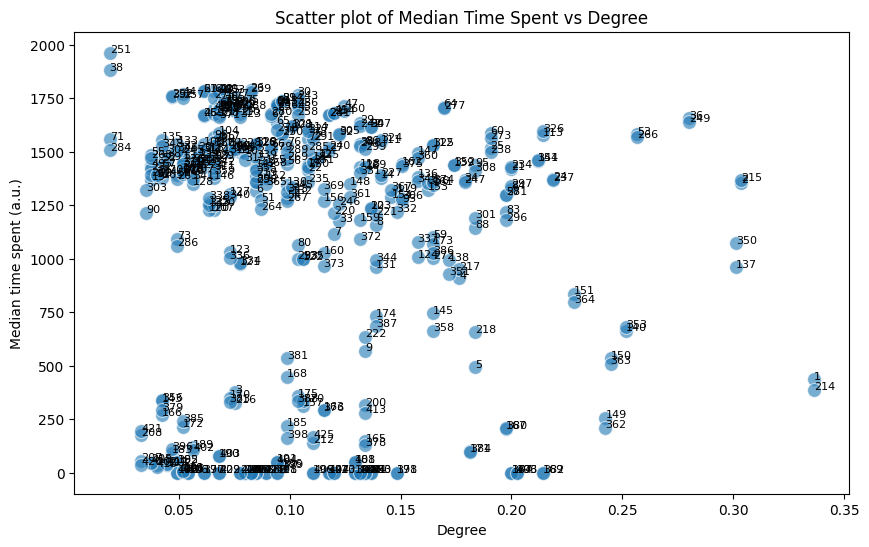

In [34]:

node_numbers = keys
# Create the scatter plot
plt.figure(figsize=(10, 6))
ax=sns.scatterplot(x=degree_val, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')

# Annotate points with node numbers
for i, txt in enumerate(node_numbers):
    ax.annotate(txt, (degree_val[i], med_time_spent[i]), fontsize=8)
# Add labels and title

# plt.xlim(0, 40)  # Adjust the range as needed
# plt.ylim(1700,2000)  
plt.xlabel('Degree')
plt.ylabel('Median time spent (a.u.)')
plt.title('Scatter plot of Median Time Spent vs Degree')

# Show the plot
plt.show()


Control nodes are (251,38),(71,284), (1,214),(149,362)

## Checking parameters for these control nodes

Node 0: FN  
Node 1: 251,38  
Node 2: 71,284  
Node 3: 1, 214  
Node 4: 149, 362





['../../data/raw/check_control/itr_200_4.bz2', '../../data/raw/check_control/itr_200_1.bz2', '../../data/raw/check_control/itr_200_3.bz2', '../../data/raw/check_control/itr_200_2.bz2', '../../data/raw/check_control/itr_200_0.bz2']
Number of transitions / 100 iteration [1, 53, 104]
Number of transition [0, 2, 4, 9, 10, 12, 15, 16, 19, 20, 21, 22, 26, 29, 31, 32, 34, 37, 38, 46, 48, 50, 51, 54, 59, 61, 64, 65, 69, 71, 72, 76, 77, 78, 79, 80, 83, 85, 89, 91, 92, 95, 96, 98, 111, 114, 116, 119, 123, 126, 127, 129, 130, 136, 138, 139, 140, 142, 146, 148, 150, 151, 152, 154, 156, 159, 162, 165, 166, 167, 169, 170, 175, 176, 180, 184, 186, 187, 189, 190, 191, 194, 195, 199]
Number of transition with more than one transition or a fall back [20, 22, 26, 29, 48, 51, 54, 78, 91, 95, 96, 111, 119, 123, 138, 140, 142, 146, 150, 151, 154, 169, 180, 184, 186, 187, 189]
Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28,

Text(0, 0.5, 'Sync Times')

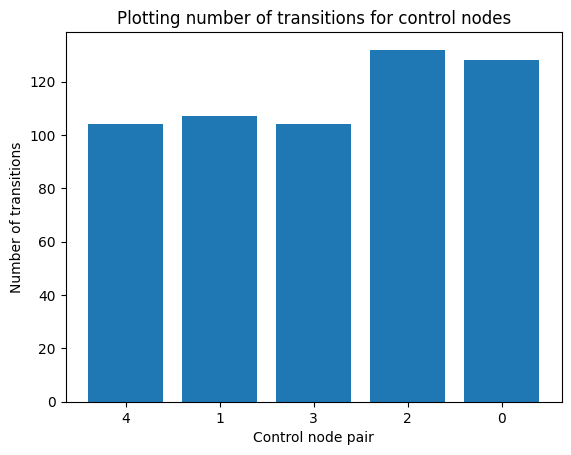

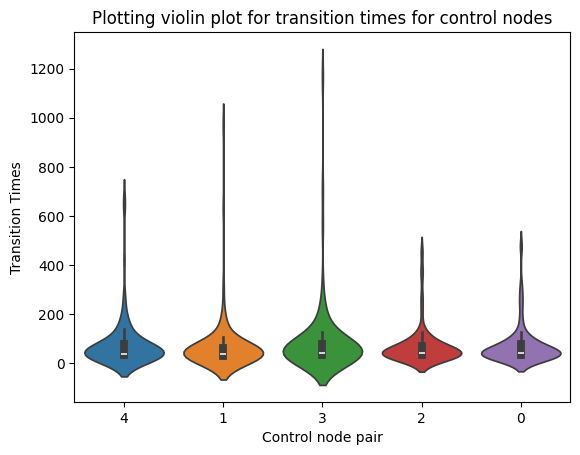

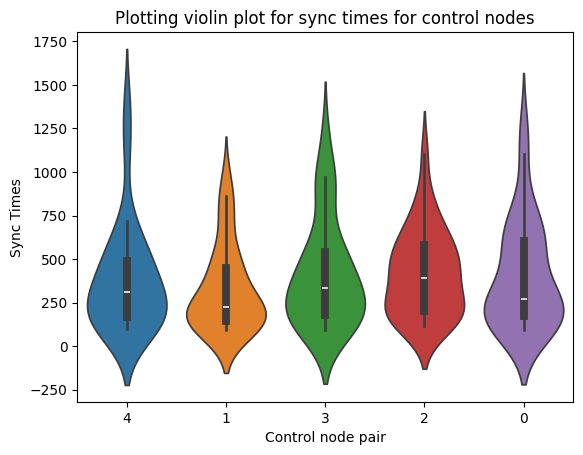

In [3]:
data_folder=Path(f'../../data/raw/check_control')

files=glob.glob(str(data_folder / "itr_200*.bz2"))
print(files)
x=[]
itr_count=[]
trans_time=[]
sync_time=[]
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    l=analyse.compute_param(df_d,0.05)
    num=l['tran_per'][-1]
    trans=l['trans']
    sync=l['sync']
    itr_count.append(num)
    trans_time.append(trans)
    sync_time.append(sync)
    

plt.figure(num=1)
plt.bar(x,itr_count)

plt.title('Plotting number of transitions for control nodes')
plt.xlabel('Control node pair')
plt.ylabel('Number of transitions')


plt.figure(num=2)
t=pd.DataFrame(trans_time).T
t.columns=x
sns.violinplot(t)
plt.title('Plotting violin plot for transition times for control nodes')
plt.xlabel('Control node pair')
plt.ylabel('Transition Times')


plt.figure(num=3)
s=pd.DataFrame(sync_time).T
s.columns=x
sns.violinplot(s)
plt.title('Plotting violin plot for sync times for control nodes')
plt.xlabel('Control node pair')
plt.ylabel('Sync Times')








## Conclusions from above

Nothing concrete could be concluded

## Analysing network measures
1. Computing connector hubs : Nodes with high degree and high betweenness centrality

In [36]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)


# Sort nodes by centrality measures
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))
top_betweenness_centrality = dict(sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True))




In [37]:
deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(deg_cent_sorted)

[1, 214, 2, 215, 137, 350, 36, 249, 53, 266, 140, 353, 150, 363, 149, 362, 151, 364, 24, 237]


In [38]:
bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(bet_cent_sorted)

[214, 1, 137, 350, 2, 215, 36, 249, 266, 53, 95, 308, 171, 384, 164, 377, 167, 380, 326, 113]


In [39]:
common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted))

In [40]:
common_node

[1, 2, 36, 137, 266, 53, 214, 215, 249, 350]